<a href="https://colab.research.google.com/github/guanyuq03/ECON5200-Applied-Data-Analytics-in-Economics/blob/main/Assignment%204/Econ_5200_Assignment_4_The_Predictive_Architecture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1> Phase 1: Causal Topology and Multicollinearity Forensics

<h2> Step 1.1: Diagnosing Spurious Clinical Signals (DAGs)

<h3> Identify the omitted confounder

The omitted confounder is baseline socioeconomic status (poverty). That is because patients with lower income are more likely to enroll in high-deductible insurance plans due to lower premiums. Meanwhile, these patients often face worse baseline health, limited access to preventive care, and higher barriers to early treatment, which increases their likelihood of inpatient admission.

<h3> DAG

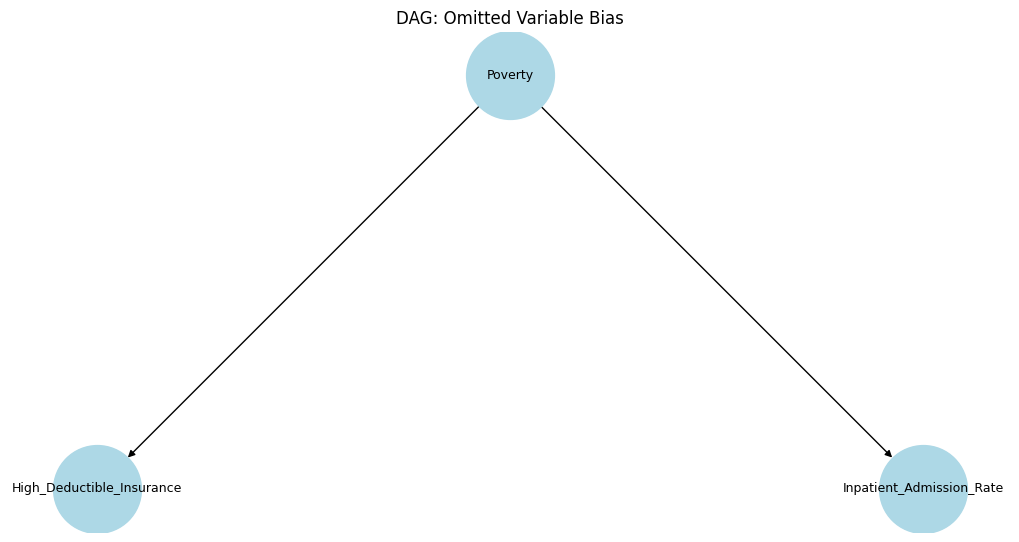

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a directed graph
G = nx.DiGraph()

# Add nodes
G.add_nodes_from([
    "Poverty",
    "High_Deductible_Insurance",
    "Inpatient_Admission_Rate"
])

# Add edges (fork structure)
G.add_edge("Poverty", "High_Deductible_Insurance")
G.add_edge("Poverty", "Inpatient_Admission_Rate")

# Define layout
pos = {
    "Poverty": (0, 1),
    "High_Deductible_Insurance": (-1, 0),
    "Inpatient_Admission_Rate": (1, 0)
}

# Draw graph
plt.figure(figsize=(10, 5))
nx.draw(G, pos, with_labels=True, node_size=4000, font_size=9, node_color="lightblue")

# Add title
plt.title("DAG: Omitted Variable Bias")

plt.show()

This graph represents a fork structure. In the graph, poverty is a common cause of both insurance type and inpatient admission.

<h3> Why the Correlation is Spurious?

As we can see from the graph, the observed relationship between high-deductible insurance and inpatient admission is driven by an open backdoor path. Because poverty affects both variables, failing to control for it creates a spurious correlation.

<h3> Why regressing Admission on Insurance Type without controlling for this confounder yields a biased, mathematically contaminated predictive weight?

Theoretically, the model is **Admission_i = α + β * HighDeductible_i + u_i**.
If we estimate it but omit poverty, then poverty becomes part of the error term: **u_i = γ * Poverty_i + ε_i**. In addition, since HighDeductible is correlated with poverty, **Cov(HighDeductible_i, u_i) ≠ 0**. This violates the OLS assumption of exogeneity, which leads to biased and inconsistent estimates of β.

<h2> Step 1.2: The Variance Inflation Factor (VIF) Audit

In [2]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Load dataset
df_clinical = pd.read_csv("https://raw.githubusercontent.com/guanyuq03/ECON5200-Applied-Data-Analytics-in-Economics/refs/heads/main/Data/OmniCare_Clinical_Vitals.csv")

# Select continuous variables
features = ["Weight_kg", "Height_cm", "BMI", "Systolic_BP", "Diastolic_BP"]

# Drop missing values
X = df_clinical[features].dropna()

# Add constant
X["Intercept"] = 1

# Compute VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print("Original VIF")
print(vif_data)

Original VIF
        Feature          VIF
0     Weight_kg    57.428058
1     Height_cm    28.419446
2           BMI    16.981232
3   Systolic_BP     4.219406
4  Diastolic_BP     4.219820
5     Intercept  3369.565806


In [3]:
# Drop BMI
features_reduced = ["Weight_kg", "Height_cm", "Systolic_BP", "Diastolic_BP"]

X2 = df_clinical[features_reduced].dropna()

# Add constant
X2["Intercept"] = 1

# Compute new VIF
vif_data2 = pd.DataFrame()
vif_data2["Feature"] = X2.columns
vif_data2["VIF"] = [
    variance_inflation_factor(X2.values, i)
    for i in range(X2.shape[1])
]

print("VIF After Dropping BMI")
print(vif_data2)

VIF After Dropping BMI
        Feature         VIF
0     Weight_kg    3.763969
1     Height_cm    3.763812
2   Systolic_BP    4.219406
3  Diastolic_BP    4.219820
4     Intercept  321.090128


Analysis:
1. Original VIF: The original VIF shows severe multicollinearity among the physiological variables. Weight_kg (57.43), Height_cm (28.42), and BMI (16.98) all exceed the critical threshold of 10. This indicates strong linear dependence among these features.
2. New VIF: The new VIF addresses the multicollinearity issue by removing BMI from the model since it is redundant given weight and height. After dropping BMI, all remaining variables have VIF values below 10: Weight_kg (3.76), Height_cm (3.76), Systolic_BP (4.22), and Diastolic_BP(4.22). This proves that the multicollinearity issue is resolved.

<h1> Phase 2: Visual Forensics and The High-Cardinality Frontier

<h2> Step 2.1: The Architecture of Missingness

In [4]:
!pip -q install missingno

<Figure size 1000x500 with 0 Axes>

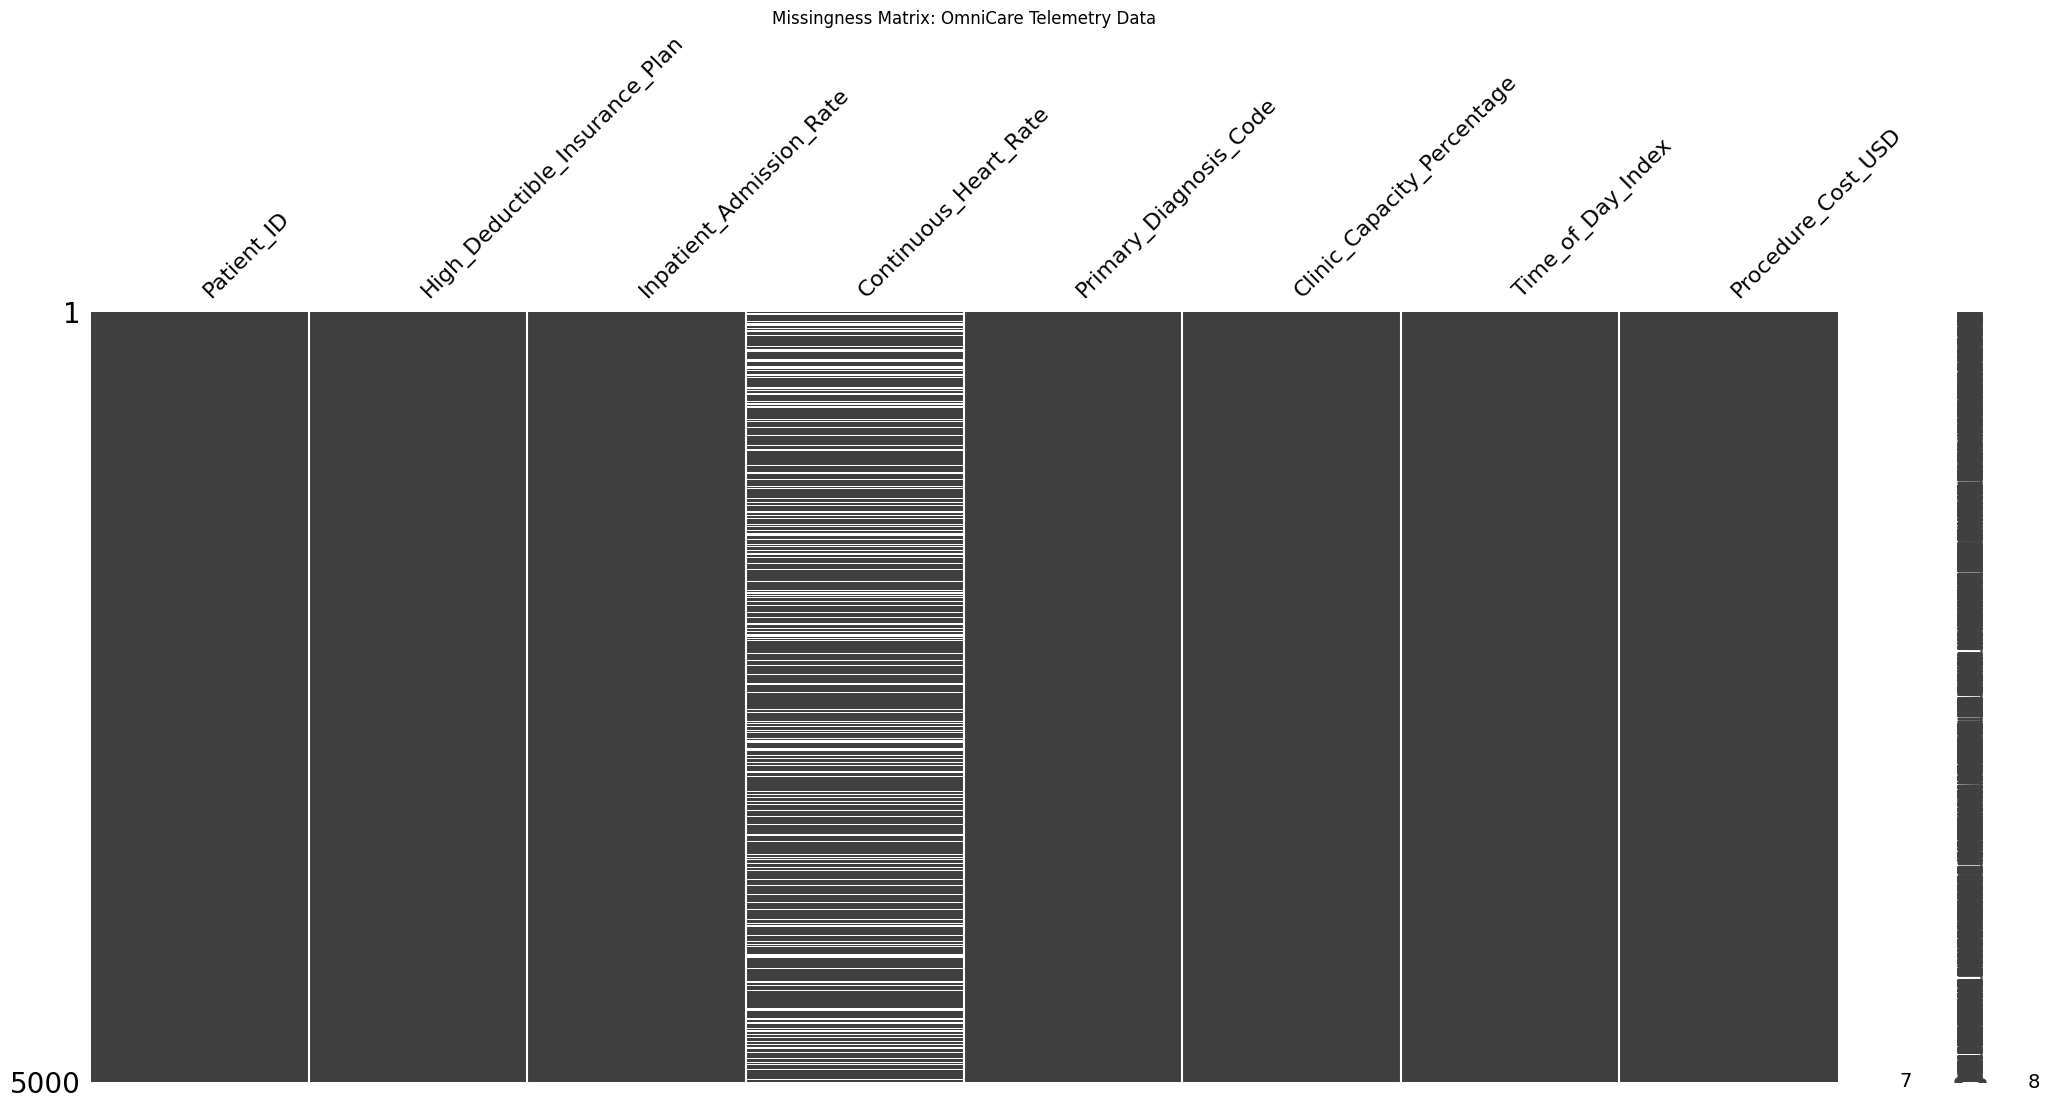

In [5]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt

# Load dataset
df_telemetry = pd.read_csv("https://raw.githubusercontent.com/guanyuq03/ECON5200-Applied-Data-Analytics-in-Economics/refs/heads/main/Data/OmniCare_Telemetry_Data.csv")

# Visualize missingness
plt.figure(figsize=(10, 5))
msno.matrix(df_telemetry)

plt.title("Missingness Matrix: OmniCare Telemetry Data")
plt.show()

Analysis:

This is **MNAR** (Missing Not At Random). The missing data is not MCAR because it is not random. The gaps happen more often for a specific group of patients. It is also not MAR because the missingness depends on income, which is not directly observed in the dataset. In addition, low-income patients are less likely to send heart rate data because of data costs. This means the probability of missing data depends on an unobserved factor (income). Therefore, it is MNAR.

Mean imputation would damage the dataset since it replaces missing values with the average. But these missing values come mostly from low-income patients, not from random patients. Using the mean would hide this difference, reduce variation in the data, and create biased results. This can lead to incorrect predictions, especially for vulnerable patients.

<h2> Step 2.2: Escaping the Dummy Variable Trap

Explain:

The variable `Primary_Diagnosis_Code` has 850 categories. Using `pd.get_dummies()` creates 850 dummy variables. For each patient, exactly one dummy equals 1, and the others are 0. In the regression, we also include an intercept (a column of all 1s). For each row, D_1 + D_2 + ... + D_850 = 1.
This is the same as the intercept. So the intercept can be written as: Intercept = D_1 + D_2 + ... + D_850. This means the variables are perfectly correlated. Because of this, the matrix \(X\) does not have full rank. So \(X'X\) is singular and cannot be inverted. The OLS formula is: β̂ = (X'X)⁻¹ X'yIf \(X'X\) cannot be inverted, we cannot compute β̂.

Solution:

We can solve the issue by dropping one dummy variable sicne the dropped category becomes the reference group, and the model can run normally.

<h2> Step 2.3: Target Encoding Implementation

In [6]:
!pip -q install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.9 MB/s eta 0:00:00


In [7]:
from category_encoders import TargetEncoder
# Create target encoder
encoder = TargetEncoder(cols=["Primary_Diagnosis_Code"])

# Fit and transform
df_telemetry["Primary_Diagnosis_Code_Encoded"] = encoder.fit_transform(
    df_telemetry["Primary_Diagnosis_Code"],
    df_telemetry["Procedure_Cost_USD"]
)

# Print first 5 rows of the encoded result
print(df_telemetry[["Primary_Diagnosis_Code", "Primary_Diagnosis_Code_Encoded"]].head())

  Primary_Diagnosis_Code  Primary_Diagnosis_Code_Encoded
0                J86.381                     1707.697108
1                M29.789                     1792.303198
2                E49.618                     1730.334968
3                E66.244                     1725.060944
4                J45.553                     1801.821085


<h1> Phase 3: Architecting the Prediction Engine

<h2> Step 3.1: OLS Optimization via Patsy Formulas

In [8]:
import statsmodels.formula.api as smf

# Merge telemetry data with cleaned clinical vitals
final_df = pd.merge(
    df_telemetry,
    df_clinical[["Patient_ID", "Weight_kg", "Height_cm", "Systolic_BP", "Diastolic_BP"]],
    on="Patient_ID",
    how="inner"
)

# Rename encoded diagnosis
final_df = final_df.rename(columns={
    "Primary_Diagnosis_Code_Encoded": "Target_Encoded_Diagnosis"
})

# Keep only the variables needed
final_df = final_df[[
    "Procedure_Cost_USD",
    "Target_Encoded_Diagnosis",
    "Clinic_Capacity_Percentage",
    "Time_of_Day_Index",
    "Weight_kg",
    "Height_cm",
    "Systolic_BP",
    "Diastolic_BP"
]].dropna()

# Define OLS formula
formula = """
Procedure_Cost_USD ~ Target_Encoded_Diagnosis
+ Clinic_Capacity_Percentage
+ Time_of_Day_Index
+ Weight_kg
+ Height_cm
+ Systolic_BP
+ Diastolic_BP
"""

# Fit model
model = smf.ols(formula=formula, data=final_df).fit()

# Display summary table
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     Procedure_Cost_USD   R-squared:                       0.243
Model:                            OLS   Adj. R-squared:                  0.242
Method:                 Least Squares   F-statistic:                     228.8
Date:                Mon, 23 Mar 2026   Prob (F-statistic):          6.83e-296
Time:                        13:21:17   Log-Likelihood:                -36162.
No. Observations:                5000   AIC:                         7.234e+04
Df Residuals:                    4992   BIC:                         7.239e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

<h2> Step 3.2: Financial Loss Quantification (RMSE)

In [9]:
from statsmodels.tools.eval_measures import rmse

# Predicted values
y_pred = model.fittedvalues

# Actual values
y_true = final_df["Procedure_Cost_USD"]

# Calculate RMSE
model_rmse = rmse(y_true, y_pred)

print("RMSE:", model_rmse)

RMSE: 334.80215211463116


Analysis:

The RMSE result (335) above measures the average prediction error in dollars. In this case, the RMSE means that the model’s predicted procedure cost is, on average, off by $335.

Compared to a typical MRI cost of `$1200`, an error of `$335` is large. This creates risks: 1. Operational risk: incorrect pricing can lead to poor scheduling and inefficient use of medical resources. 2. Financial risk: the hospital may lose revenue if procedures are underpriced or lose patients if prices are too high. 3. Regulatory risk: pricing errors may appear unfair, especially if certain patient groups are systematically overcharged or undercharged.

<h2> Step 3.3: Residual Diagnostics for Heteroscedasticity

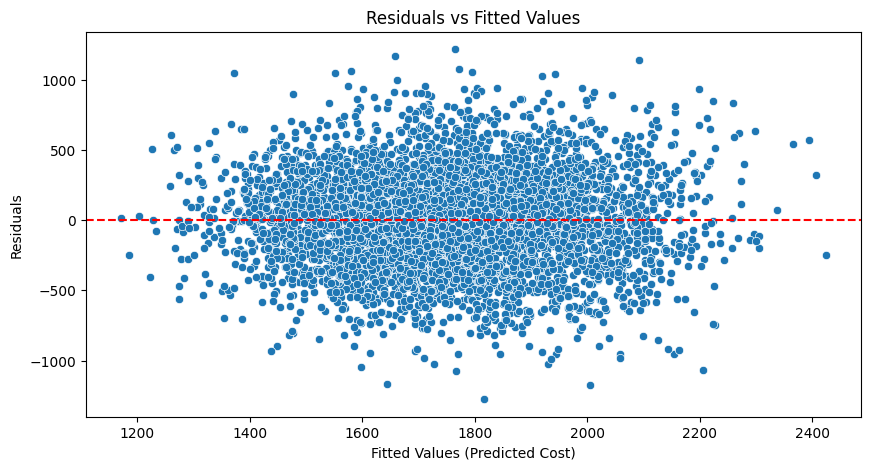

In [10]:
import seaborn as sns

# Get fitted values and residuals
fitted_vals = model.fittedvalues
residuals = model.resid

# Plot
plt.figure(figsize=(10, 5))
sns.scatterplot(x=fitted_vals, y=residuals)

# Add horizontal line at 0
plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Fitted Values (Predicted Cost)")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")

plt.show()

Analysis:

From the scatter plot, the residuals are centered around zero. There is a slight increase in the spread of residuals as the predicted procedure cost increases, but the pattern is not very strong. This suggests mild evidence of heteroscedasticity rather than a clear fan-shaped pattern. This indicates that the variance of the errors is not perfectly constant, and the model produces slightly larger and more variable errors at higher predicted cost levels.

In a surge-pricing setting, this is concerning because the model becomes less reliable at higher price tiers. Since high-cost procedures are more sensitive and financially important, even moderate instability can lead to noticeable pricing errors and unreliable pricing decisions.

<h1> Phase 4: AI Context Engineering (The P.R.I.M.E. Framework)

<h2> Task 4.1: Lagrange Multiplier Test for Heteroscedasticity

<h2> My P.R.I.M.E. prompt:

1. You are an expert econometrician and Python coding assistant. You specialize in statsmodels, regression diagnostics, and writing clean Google Colab code for undergraduate economics assignments.
2. Act as my programmer for ECON 5200. I have already fit an OLS model in Python using statsmodels.formula.api. The fitted model object is named `model`, and it was estimated on my final analytical dataframe using these variables: Dependent variable:Procedure_Cost_USD. Independent variables:Target_Encoded_Diagnosis, Clinic_Capacity_Percentage, Time_of_Day_Index, Weight_kg, Height_cm, Systolic_BP, Diastolic_BP. I now need to test this exact fitted OLS model for heteroscedasticity using White’s Lagrange Multiplier Test.
3. Write a Python script that uses `statsmodels.stats.diagnostic.het_white` to run White’s test on my already-fitted model object `model`.
4. This test is for my ECON 5200 assignment on predictive architecture in healthcare pricing. I need a formal heteroscedasticity diagnostic after fitting my OLS pricing model. The output must be easy to copy into my notebook and easy for an international student to understand. The goal is to produce a correct p-value and a final conclusion sentence about whether homoscedasticity is rejected.
5. The code should run directly after my existing OLS model code, uses `het_white` correctly, print the LM p-value clearly,include a correct conclusion about rejecting or not rejecting the null, and it avoids unnecessary complexity.

In [11]:
from statsmodels.stats.diagnostic import het_white

# Run White's test
white_test = het_white(model.resid, model.model.exog)

# Store results
lm_stat = white_test[0]
lm_pvalue = white_test[1]
f_stat = white_test[2]
f_pvalue = white_test[3]

# Print results
print("White LM Statistic:", lm_stat)
print("White LM Test p-value:", lm_pvalue)
print("White F-Statistic:", f_stat)
print("White F-Test p-value:", f_pvalue)

# Conclusion
if lm_pvalue < 0.05:
    print("Conclusion: Reject the null hypothesis of homoscedasticity.")
else:
    print("Conclusion: Fail to reject the null hypothesis of homoscedasticity.")

White LM Statistic: 186.46773970660723
White LM Test p-value: 1.4380291432919198e-22
White F-Statistic: 5.494188406766981
White F-Test p-value: 4.4790231228469927e-23
Conclusion: Reject the null hypothesis of homoscedasticity.


The LM test p-value is extremely small (p < 0.05). Therefore, we reject the null hypothesis of homoscedasticity. This provides strong statistical evidence that heteroscedasticity is present in the model, meaning that the variance of the residuals is not constant.